# WINDMI Isolated Substorm Detection — Multi-Year Run (1998–2004)

This notebook runs the WINDMI model over the full 1998–2004 interval and evaluates substorm onset detection performance against the merged reference catalog from Adhya et al. (2025).

1. ACE solar-wind data are loaded year-by-year, propagated to the magnetopause, and resampled to a 1-minute grid.
2. The VBs solar-wind coupling voltage is computed.
3. WINDMI is run in three configurations (Cases 1–3) and Run 1 outputs are saved to disk.
4. Isolated substorms are identified from the merged catalog and WINDMI detection is scored for each configuration.
5. Detection performance is summarised by substorm strength (SME) and catalog count score, producing the paper figures.

> **Before running:** update `ACE_dir` and all other hardcoded paths to point to your local data directory.


## Imports


In [ ]:
import os
import datetime as dt
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from tqdm import tqdm
from numpy import sin, pi
# %matplotlib widget

## Simulation interval

Start and stop times for the multi-year run. All data loading and model runs are bounded by this window.


In [ ]:
start = dt.datetime(1998,1,1); 
stop = dt.datetime(2005,1,1);

## Solar wind and SuperMAG data

ACE Level-2 files are loaded year by year and concatenated into a single DataFrame. A ±2-hour buffer is applied before trimming to the simulation window. Rows with NaN values are dropped.


In [ ]:
ACE_dir = "C:/Users/soumy/OneDrive/Documents/src/2024-04 WINDMI Identification/data1/";
os.chdir(ACE_dir)

years = range(start.year, stop.year + 1)
dfs = []

for yr in years:
    fname = f"ACE_{yr}.csv"
    df = pd.read_csv(fname)

    df.index = pd.to_datetime(df["Time"])
    df = df.drop(columns=["Time"])

    dfs.append(df)

data = pd.concat(dfs).sort_index()

# apply time window (with ±2 hours padding)
data = data.loc[start - dt.timedelta(hours=2) : stop + dt.timedelta(hours=2)]

# remove rows with NaN values
data = data.dropna()

SuperMAG files are loaded year by year. The column name for the timestamp differs between years (pre-2010: `Date_UTC`; 2010+: `time`), so a conditional branch handles both formats. The SML index is used as an observational reference in the figures.


In [ ]:
# Multi-year SuperMAG loading

dfs = []

for yr in range(start.year, stop.year + 1):
    fname = f"C:/Users/soumy/OneDrive/Documents/src/2024-04 WINDMI Identification/Data0/SuperMag_{yr}.csv"
    df = pd.read_csv(fname)

    if yr < 2010:
        df.index = pd.to_datetime(df["Date_UTC"])
        df = df.drop(columns=["Date_UTC"])
    else:
        df.index = pd.to_datetime(df["time"])
        df = df.drop(columns=["time"])
        df.index = df.index.tz_localize(None)

    dfs.append(df)

SuperMag = pd.concat(dfs).sort_index()

# apply same time window if needed
SuperMag = SuperMag.loc[start:stop]

## Calculate the time delay

The time-varying propagation delay is computed using the Shue et al. (1998) magnetopause standoff distance. Each ACE measurement is shifted to the dayside magnetopause before being used as a model driver.


In [ ]:
# time_substorm = np.arange(200, 600, 1)  # time indices for substorm interval
Dp = 1.67e-6 * data['Np'] * data['Vx']**2  # dynamic pressure in nPa
R_subsolar = (10.22 + 1.29*np.tanh(0.184*(data['Bz'] + 8.14))) * (Dp**(-1/6.6))  # subsolar magnetopause standoff distance in RE  
t_delay = -((250.0 - np.nanmean(R_subsolar)) * 6380.0) / np.nanmean(data['Vx'])  # for constant delay
t_delay_windmi = -((250.0 - R_subsolar) * 6380.0) / data['Vx'].rolling(window=20, min_periods=1, center=True).mean()  # time delay array for WINDMI model


## Shift the ACE Data

`apply_windmi_time_shift` shifts the ACE timestamps by the local propagation delay and resamples onto a uniform 1-minute grid via linear interpolation. Duplicate timestamps and NaT indices are removed before resampling.


In [ ]:
def apply_windmi_time_shift(data, t_delay_windmi):
    data_shifted = data.copy()
    # Shift time index by time-varying delay (seconds)
    data_shifted.index = data_shifted.index + pd.to_timedelta(
        t_delay_windmi, unit="s")
    data_shifted = data_shifted.sort_index()
    data_shifted = data_shifted[~data_shifted.index.isna()]
    #remove duplicate indices after shifting
    data_shifted = data_shifted[~data_shifted.index.duplicated(keep='first')]

    t_start = data_shifted.index.min().floor("min")
    t_end   = data_shifted.index.max().ceil("min")
    x0 = np.array((data_shifted.index - t_start)/dt.timedelta(seconds=1))  # original time index in seconds
    x1_time = pd.date_range(t_start, t_end, freq="1min")      # <- whole minutes
    x1 = np.array((x1_time - t_start)/dt.timedelta(seconds=1))  # resampled time index in seconds 
    df = pd.DataFrame(index=x1_time)
    for col in data_shifted.columns:
        y0 = data_shifted[col].values
        y1 = interp1d(x0, y0, kind="linear", bounds_error=False, fill_value=np.nan)(x1)
        df[col] = y1
    #remove rows with NaN values
    
    df = df.dropna().reset_index()
    df = df.set_index('index')
    return df

data = apply_windmi_time_shift(data, t_delay_windmi)
data = data.loc[start:stop];

## Calculate the input voltage

Three coupling voltage formulations are computed. The **VBs** formula is selected as the WINDMI driver and stored as `data['vBs']`. The Siscoe–Hill and Newell formulations are retained for reference.


In [ ]:
Bx = data['Bx']; By = data['By']; Bz = data['Bz']; # IMF components in nT
Vx = data['Vx']; Vy = data['Vy']; Vz = data['Vz']; # Solar wind velocity components in km/s
Np = data['Np']; # Solar wind proton density in cm^-3 

In [ ]:
# Input voltages
R_E = 6380.0e3  # Earth radius in m
Ly = 10.0 * R_E # effective width of magnetosphere in solar wind dynamo

# VBs formula
Bz_input = 0.5 * (np.abs(Bz) - Bz)  # if Bz < 0, Bz_input = |Bz| else Bz_input = 0
Vsw0 = 4000.0 + (1.0e-6 * Ly * np.abs(Vx * Bz_input))  # Solar wind coupling function

# Siscoe-Hill formula
m_p = 1.67e-27  # mass of proton in kg
B_abs = np.abs(Bx**2 + By**2 + Bz**2) # magnitude of IMF in nT
theta = np.arccos(Bz/B_abs)  # IMF clock angle in radians
v_sw = np.sqrt(Vx**2 + Vy**2 + Vz**2)  # solar wind speed in km/s
Esw = (v_sw*1e3) * (np.sqrt(By**2 + Bz**2)*1e-9) * np.sin(theta/2.0);
Psw = m_p * (Np * 1.0e6) * ((v_sw*1.0e3)**2)  # solar wind dynamic pressure in Pa
Phi_M = 30.0 + (57.6 * (Esw*1.0e3) * ((1.0e9 * Psw) ** (-1.0 / 6.0))) # magnetospheric potential in kV
Vsw1 = 1e3*Phi_M;

C0 = 0.77;
F107 = 172.42; # its supposed to be monthly mean
SigmaP = C0 * np.sqrt(F107);
Phi_S = 1600.0 * ((Psw*1.0e9)**(1/3))/SigmaP # saturation voltage
Phi_H = (Phi_M * Phi_S) / (Phi_M + Phi_S)  # Hill potential

# Newell et al. 2007
DPhi_mp = (np.abs(Vx)**(4/3)) * (B_abs**(2/3)) * (np.sin(theta / 2.0)**(8/3))  # dayside reconnection rate in kV
Vsw2 = 4000.0 + (np.mean(Vsw0)/np.mean(DPhi_mp))*DPhi_mp;  # scaled Newell coupling function

data['vBs'] = Vsw0;  # choose VBs as input voltage for WINDMI model

c:\Users\soumy\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Substorm lists

The five individual onset lists and the merged reference catalog are loaded. The `score` column in the merged catalog records how many of the five lists identified each event (1–5).


In [ ]:
# Get the substorm lists
keywords = ['Forsyth', 'Frey','Liou','Newell','Ohtani']

for key in keywords:
    filename = ACE_dir +  f"../Data0/Substorms_{key}_1970_to_2022.csv";
    df = pd.read_csv(filename)
    df.index = pd.to_datetime(df['Date_UTC'])
    # globals()[f"{key}"] = df.loc[start:stop]
    globals()[f"{key}"] = df;

In [ ]:
substorms_all = pd.read_csv(ACE_dir + "../Data1/Substorms_all_09-30.csv")
substorms_all.index = pd.to_datetime(substorms_all['Date_UTC'])
substorms_all = substorms_all.loc[start:stop]
substorms_all['score'] = substorms_all['Forsyth'] + substorms_all['Frey'] + substorms_all['Liou'] + substorms_all['Newell'] + substorms_all['Ohtani'];

# WINDMI code

Default model parameters, the ODE right-hand side (`windmi_rhs`), the onset trigger function (`_H_switch`), and the RK45 solver wrapper (`solve_windmi_rk45`) are defined here. These are identical to those in `WINDMI_paper_1.ipynb`; refer to that notebook for detailed documentation.


In [ ]:
# create a dictionary of inputs
p = {
    # --- Inductances ---
    "L": 90.0,                    # Inductance of the lobe cavity
    "L1": 20.0,                    # Region-1 current inductance
    "L2": 8.0,                     # Ring current inductance

    "L_y": 3.2e7,                  # Cross-tail length scale [m]

    # --- Capacitances ---
    "C": 5.0e4,                   # Plasma sheet capacitance
    "C1": 8.0e2,                   # capacitance of R1 current loop

    # --- Resistances ---
    "R_prc": 0.1,                  # Partial ring current resistance
    "R_A2": 0.3,                   # Region-2 Alfven resistance

    "M": 0.1,                      # mutual inductance between I and I1 (in the paper its 1.0?)

    # --- Currents ---
    "DeltaI": 1.25e5,              # Delta I in theta function

    # --- Conductances ---
    "Sigma": 8.0,                  # Plasma sheet conductance
    "SigmaI": 3.0,                 # pedersen conductance of westward electrojet current

    # --- Magnetic / EM constants ---
    "u0": 4.2e-9,                 # heat flux limit paramter
    "Aeff": 8.14e13,              # Effective cross-sectional area [m^2]
    "Btr": 5.0e-9,                # Trigger magnetic field threshold [T]

    # --- Energetics ---
    "Omega_cps": 2.6e24,           # Plasma sheet volume
    "Alpha": 8.0e11,               # Energy coupling coefficient

    # --- Time constants ---
    "tauE": 30.0 * 60.0,          # Energy decay timescale [s]
    "tauk": 10.0 * 60.0,          # confinement time of parallel flow [s]
    "taurc": 12.0 * 3600.0,       # Ring current decay time [s]
            
    "beta_sw": 0.7,               # Coupling factor for SW across magnetopause

    "Ic_trig": 2.0e7              # Threshold current for substorm onset in A    
}

In [ ]:
def _H_switch(I, Ic, DeltaI):
    # Eq. (17): H(I - Ic) = 0.5 * (1 + tanh((I - Ic)/DeltaI))
    return 0.5 * (1.0 + np.tanh((I - Ic) / DeltaI))

def windmi_rhs(t, p, x, Vsw):
    """
    State vector (paper): X(t) = (I, V, I1, VI, p, Kk, I2, Wrc)
    Eqs. (9)-(16) in Spencer & Horton (2006). :contentReference[oaicite:2]{index=2}
    """

    I, V, I1, VI, pres, Kk, I2, Wrc = x
    ## WINDMI constants and parameters
    L = p["L"] ;L1 = p["L1"]; L2 = p["L2"] ; L_y = p["L_y"];                  
    C = p["C"]; C1 = p["C1"];
    R_prc = p["R_prc"]; R_A2 = p["R_A2"];

    M = p["M"]; DeltaI = p["DeltaI"]; SigmaI = p["SigmaI"];
    u0 = p["u0"]; Aeff = p["Aeff"]; Btr = p["Btr"];
    
    Omega_cps = p["Omega_cps"]; Alpha = p["Alpha"];
    tauE = p["tauE"]; tauk = p["tauk"]; taurc = p["taurc"]; beta_sw = p["beta_sw"];

    # The real players 
    L = p["L"]; C = p["C"]; Sigma = p["Sigma"]; Ic_trig = p["Ic_trig"];

    # --- derived terms ---
    H = _H_switch(I, Ic_trig, DeltaI)

    # --- failsafe for non-physical negative values ---
    pres = max(pres, 0.0);
    Kk   = max(Kk,   0.0);
    Wrc  = max(Wrc,  0.0);

    Ips = Alpha * np.sqrt(max(pres, 0.0))  # Ips = a p^{1/2}

    # Unloading / injection coupling term used in Eq. (11) and Eq. (16)
    # (paper term appears as p V Aeff / (Xcps Btr Ly) in Eq. 11 and p V Aeff / (Btr Ly) in Eq. 16)
    inj_ps = (pres * V * Aeff) / (Omega_cps * Btr * L_y)
    inj_rc = (pres * V * Aeff) / (Btr * L_y)

    # --- Solve the coupled inductive pair (Eqs. 9 & 13) for dI/dt and dI1/dt ---
    # Eq (9):  L dI/dt  = bsw Vsw - V + M dI1/dt
    # Eq (13): LI dI1/dt = V - VI + M dI/dt
    # Write as:
    # [ L   -M ] [dI ] = [ bsw Vsw - V ]
    # [ -M  LI ] [dI1]   [ V - VI       ]
    A = np.array([[L, -M],
                [-M, L1]], dtype=float)
    b = np.array([beta_sw*Vsw - V,
                V - VI], dtype=float)

    detA = A[0,0]*A[1,1] - A[0,1]*A[1,0]   # = L*L1 - M^2

    # failsafe thresholds (tune if needed)
    eps_det = 1e-12
    max_cond = 1e12

    if abs(detA) < eps_det or np.linalg.cond(A) > max_cond:
        # fallback: least-squares / pseudo-inverse (won’t crash)
        dI, dI1 = np.linalg.lstsq(A, b, rcond=None)[0]
    else:
        dI, dI1 = np.linalg.solve(A, b)

    # Eq (10): C dV/dt = I - I1 - Ips - R V
    dV = (I - I1 - Ips - Sigma*V) / C

    # Eq (11): (3/2) dp/dt = R V^2 / Xcps - u0 p Kk^{1/2} H - p V Aeff/(Xcps Btr Ly) - (3p)/(2 tauE)
    # => dp/dt = (2/3)*[ ... ]
    dP = (2.0/3.0) * ( ((Sigma * V * V) / Omega_cps)
                       - (u0 * pres * np.sqrt(max(Kk, 0.0)) * H)
                       - inj_ps
                       - ((3.0 * pres)/(2.0 * tauE)) )

    # Eq (12): dKk/dt = Ips V - Kk/tauk
    dKk = Ips * V - (Kk / tauk)

    # Eq (14): CI dVI/dt = I1 - I2 - RI VI
    dVI = (I1 - I2 - (SigmaI * VI)) / C1

    # Eq (15): L2 dI2/dt = VI - (Rprc + RA2) I2
    dI2 = (VI - ((R_prc + R_A2) * I2)) / L2

    # Eq (16): dWrc/dt = Rprc I2^2 + p V Aeff/(Btr Ly) - Wrc/taurc
    dWrc = (R_prc * (I2**2)) + inj_rc - (max(Wrc, 0.0) / taurc)

    return np.array([dI, dV, dI1, dVI, dP, dKk, dI2, dWrc], dtype=float)

def solve_windmi_rk45(t_seconds,
                      p,
                      Vsw,
                      x0=None, 
                      rtol=1e-6, 
                      atol=1e-9,  
                      Ic_trig=None,
                      L = None, C = None, Sigma = None):
    
    t_seconds = np.asarray(t_seconds, dtype=float);
    Vsw = np.asarray(Vsw, dtype=float);
    # default initial condition if not provided
    if x0 is None:
        x0 = np.zeros(8, dtype=float)
    else:
        x0 = np.asarray(x0, dtype=float)
        if x0.shape != (8,):
            raise ValueError("x0 must be shape (8,) = [I, V, I1, VI, p, Kk, I2, Wrc]")
    Vsw_of_t = interp1d(
        t_seconds, Vsw,
        kind="linear",
        bounds_error=False,
        fill_value=(Vsw[0], Vsw[-1])
    )
    p.update({
    k: v for k, v in {
        "Ic_trig": Ic_trig,
        "L": L,
        "C": C,
        "Sigma": Sigma
    }.items() if v is not None
})
    def rhs(t, x):
        return windmi_rhs(t, p, x, Vsw_of_t(t))
    sol = solve_ivp(rhs, 
                    (t_seconds[0], t_seconds[-1]), 
                    y0=x0, 
                    t_eval=t_seconds, 
                    rtol=rtol, 
                    atol=atol,
                    max_step=60.0)
    if not sol.success:
        k = -1 if sol.t.size > 0 else None
        if k is not None:
            print("FAIL t =", sol.t[k])
            print("STATE @ fail:", sol.y[:, k])
        print("MESSAGE:", sol.message)
        raise RuntimeError(sol.message)
    return {
        "t": sol.t,
        "I":   sol.y[0],
        "V":   sol.y[1],
        "I1":  sol.y[2],
        "VI":  sol.y[3],
        "pres":   sol.y[4],
        "Kk":  sol.y[5],
        "I2":  sol.y[6],
        "Wrc": sol.y[7]}, p


# Case 1: Constant L,C,sigma + daily Ic

L, C, and Σ are fixed at their default constant values. *I_c* is set once per day as the 70th percentile of *I(t)* over that calendar day (computed from Run 1).

Only Run 1 (no onset trigger) is executed over the full seven-year interval. The trigger-on loop (Run 2) is commented out to reduce runtime. Run 1 output is saved to disk for use in the detection analysis.

In [ ]:
## Trigger off
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
p0 = p.copy();
out,_ = solve_windmi_rk45(t_seconds,
                        p0, 
                        data['vBs'])  # run windmi with no trigger

out_no_trig = pd.DataFrame(
    {
        "I":   out["I"],
        "V":   out["V"],
        "I1":  out["I1"],
        "VI":  out["VI"],
        "pres":out["pres"],
        "Kk":  out["Kk"],
        "I2":  out["I2"],
        "Wrc": out["Wrc"],
    },
    index=data.index
)

# ## Trigger on
# no_of_days = (stop - start).days
# x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # initial condition
# out_trig = pd.DataFrame()
# for i in tqdm(range(no_of_days)):
#     mask = (
#         (data.index >= start + dt.timedelta(days=i)) &
#         (data.index < start + dt.timedelta(days=i+1) - dt.timedelta(minutes=1))
#     )

#     t_seconds_day = np.array((data.index[mask] - start)/dt.timedelta(seconds=1))
#     v_sw_day = data.loc[mask, 'vBs']

#     Ic_trig_day = np.percentile(out_no_trig.loc[mask, 'I'], 70.0)
    
#     out_dict, _ = solve_windmi_rk45(
#         t_seconds=t_seconds_day,
#         p=p0,
#         Vsw=v_sw_day,
#         x0=x0,
#         Ic_trig=Ic_trig_day
#     )
#     out_trig = pd.concat([out_trig, pd.DataFrame(
#     {
#         "I":   out_dict["I"],
#         "V":   out_dict["V"],
#         "I1":  out_dict["I1"],
#         "VI":  out_dict["VI"],
#         "pres":out_dict["pres"],
#         "Kk":  out_dict["Kk"],
#         "I2":  out_dict["I2"],
#         "Wrc": out_dict["Wrc"],
#         "I_c":  Ic_trig_day*np.ones_like(out_dict["I"])
#     },
#     index=data.index[mask]
# )])
   
#     # update initial condition for next day
#     x0 = np.array([
#         out_dict['I'][-1],
#         out_dict['V'][-1],
#         out_dict['I1'][-1],
#         out_dict['VI'][-1],
#         out_dict['pres'][-1],
#         out_dict['Kk'][-1],
#         out_dict['I2'][-1],
#         out_dict['Wrc'][-1]
#     ])

In [ ]:
out_no_trig_0 = out_no_trig.copy()
# out_trig_0 = out_trig.copy()

In [ ]:
# save out_no_trig_0 and out_trig_0 to csv files
# out_no_trig_0.to_csv(f"F:/Temp/out_no_trig_case_0_{start.date()}_{stop.date()}.csv")
out_no_trig_0.to_csv(f"C:/Users/soumy/OneDrive/Documents/Temp/out_no_trig_case_0_{start.date()}_{stop.date()}.csv")

# Case 2: Constant L,C,Sigma + Ic(t)

L, C, and Σ remain at their default constant values. *I_c* is updated at every time step as the 70th percentile of *I* over the preceding three hours (180-point rolling window on 1-min data).

Only Run 1 is executed. The rolling *I_c* series is derived from the Run 1 output and used directly for detection scoring. Run 1 output is saved to disk.

In [ ]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
p1 = p.copy();
out,_ = solve_windmi_rk45(t_seconds,
                        p1, 
                        data['vBs'])  # run windmi with no trigger
out_no_trig = pd.DataFrame(
    {
        "I":   out["I"],
        "V":   out["V"],
        "I1":  out["I1"],
        "VI":  out["VI"],
        "pres":out["pres"],
        "Kk":  out["Kk"],
        "I2":  out["I2"],
        "Wrc": out["Wrc"],
    },
    index=data.index)
rolling_Ic = out_no_trig['I'].rolling(window=60*3, min_periods=1).quantile(0.7)

# out_trig_rolling = pd.DataFrame()
# x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]);
# for i in tqdm(range(len(data.index)-1)):
#     t_seconds_i = np.array((data.index[i:i+2] - start)/dt.timedelta(seconds=1))  # time in seconds for current step
#     v_sw_i = data.loc[data.index[i:i+2], 'vBs']
#     Ic_trig_i = rolling_Ic.iloc[i]

#     out_dict_i,_ = solve_windmi_rk45(
#         t_seconds=t_seconds_i,
#         p=p1,
#         Vsw=v_sw_i,
#         x0=x0,
#         Ic_trig=Ic_trig_i
#     )
#         # --- minimal fix: only add non-overlapping rows ---
#     if i == 0:
#         idx = data.index[i:i+2]
#         sl  = slice(None)          # take both rows only for the first iteration
#     else:
#         idx = data.index[i+1:i+2]  # take only the NEW row (the second one)
#         sl  = slice(1, None)       # take only out_dict_i[1]
#     # -----------------------------------------------

#     out_trig_rolling = pd.concat([out_trig_rolling, pd.DataFrame(
#         {
#             "I":   out_dict_i["I"][sl],
#             "V":   out_dict_i["V"][sl],
#             "I1":  out_dict_i["I1"][sl],
#             "VI":  out_dict_i["VI"][sl],
#             "pres":out_dict_i["pres"][sl],
#             "Kk":  out_dict_i["Kk"][sl],
#             "I2":  out_dict_i["I2"][sl],
#             "Wrc": out_dict_i["Wrc"][sl],
#             "I_c": Ic_trig_i*np.ones_like(out_dict_i["I"][sl]),
#         },
#         index=idx
#     )])

#     # update initial condition for next step
#     x0 = np.array([
#         out_dict_i['I'][-1],
#         out_dict_i['V'][-1],
#         out_dict_i['I1'][-1],
#         out_dict_i['VI'][-1],
#         out_dict_i['pres'][-1],
#         out_dict_i['Kk'][-1],
#         out_dict_i['I2'][-1],
#         out_dict_i['Wrc'][-1]
#     ])



In [ ]:
out_no_trig_1 = out_no_trig.copy()
# out_trig_1 = out_trig_rolling.copy()

# save out_no_trig_1 and out_trig_1 to csv files
out_no_trig_1.to_csv(f"C:/Users/soumy/OneDrive/Documents/Temp/out_no_trig_case_1_{start.date()}_{stop.date()}.csv")
# out_trig_1.to_csv(f"C:/Users/soumy/OneDrive/Documents/Temp/out_trig_case_1_{start.date()}_{stop.date()}.csv")

# Case 3: Variable L,C,Sigma + I_c(t)

L(t), C(t), and Σ(t) are computed from real-time solar-wind conditions at each 1-minute step, together with a rolling *I_c(t)*.

`calc_L_C_Sigma` derives the three parameters empirically using the Shue et al. (1998) magnetopause model and Borovsky (1998) plasma-sheet relations. See `WINDMI_paper_1.ipynb` for details.

Run 1 uses pre-allocated NumPy arrays for efficiency over the seven-year interval. The rolling *I_c* and Θ series are computed from the Run 1 output. Run 2 (with the onset trigger active) follows. Run 1 output is saved to disk.

In [ ]:
def calc_L_C_Sigma(data,
                    L_x=80.0,
                    L_y=50.0,
                    L_z=1.0,
                    r = 40.0,
                    B_x0 = 10.0e-9,
                    B_z0 = 0.1e-9
):

    mu0 = 4*pi*1.0e-7  # permeability of free space
    R_E = 6380.0e3;  # Earth radius in m
    L_x = L_x * R_E;
    L_y = L_y * R_E;
    L_z = L_z * R_E; ## consider changing it
    e = 1.6e-19;  # elementary charge in C
    k_B = 1.38e-23  # Boltzmann constant in J/K
    m_p = 1.67e-27;  # mass of proton in kg

    Dp = 1.67e-6 * data['Np'] * data['Vx']**2  # dynamic pressure in nPa
    r_0 = (10.22 + 1.29*np.tanh(0.184*(data['Bz'] + 8.14))) * (Dp**(-1/6.6))  # subsolar magnetopause standoff distance in RE  
    #r = 25;  # reference distance for scaling (e.g., 40 RE in the tail)
    alpha_s = (0.58 - (0.007*data['Bz']))*(1 + (0.024*np.log(Dp)))  # flaring parameter from Shinohara et al. (1998)

    r_lobe = r * sin(np.arccos(2*((r_0/r)**(1/alpha_s)) - 1)) # lobe radius at distance r in R_E
    A_lobe = pi * ((r_lobe*R_E)**2)/2  # semi-circle area of the lobe at distance r
    L = mu0 * A_lobe  / L_x  # inductance of the lobe cavity

    n_ps = 0.292 * (data['Np']**0.49);  # plasma sheet density in cm^-3 from Borovsky et al. (1998)
    n_ps = n_ps * 1.0e6;  # convert to m^-3
    rho_ps = n_ps * m_p;  # plasma sheet mass density in kg/m^3
    # B_x0 = 10.0e-9;  # reference magnetic field strength in T (10 nT)
    # B_z0 = 0.1e-9;  # reference magnetic field strength in T (0.1 nT)
    C = np.pi * (L_x*L_z/L_y) * (rho_ps/(B_x0*B_z0))  # effective capacitance of the plasma sheet

    v_sw = np.sqrt(data['Vx']**2 + data['Vy']**2 + data['Vz']**2)  # solar wind speed in km/s

    T_cps = 2.17 + (0.0223*v_sw)  # central plasma sheet temperature in keV from Brorovsky et al. (1998)
    T_cps = T_cps * 1.0e3 * e / k_B  # convert to Kelvin
    rho_i = np.sqrt(m_p * k_B * T_cps) / (e * B_x0)  # ion gyroradius in m

    Sigma = 0.1 * (L_x*L_z/L_y) * (e*n_ps/B_x0) * np.sqrt(rho_i/L_z)
    return L, C, Sigma

L,C,Sigma = calc_L_C_Sigma(data)

In [ ]:
#slightly changed for faster runtime
t_seconds = ((data.index - start) / dt.timedelta(seconds=1)).to_numpy()
vbs = data["vBs"].to_numpy()

n = len(data)

# initial condition
x0 = np.zeros(8)
p2 = p.copy()

# preallocate output
out_arr = np.empty((n, 8))
out_arr[:] = np.nan

for i in tqdm(range(n - 1)):
    t_seconds_i = t_seconds[i:i+2]
    v_sw_i = vbs[i:i+2]

    out_dict_i, p2 = solve_windmi_rk45(
        t_seconds=t_seconds_i,
        p=p2,
        Vsw=v_sw_i,
        x0=x0,
        Ic_trig=None,
        L=L[i],
        C=C[i],
        Sigma=Sigma[i]
    )

    vals = np.array([
        out_dict_i["I"][-1],
        out_dict_i["V"][-1],
        out_dict_i["I1"][-1],
        out_dict_i["VI"][-1],
        out_dict_i["pres"][-1],
        out_dict_i["Kk"][-1],
        out_dict_i["I2"][-1],
        out_dict_i["Wrc"][-1]
    ])

    if i == 0:
        out_arr[0, :] = np.array([
            out_dict_i["I"][0],
            out_dict_i["V"][0],
            out_dict_i["I1"][0],
            out_dict_i["VI"][0],
            out_dict_i["pres"][0],
            out_dict_i["Kk"][0],
            out_dict_i["I2"][0],
            out_dict_i["Wrc"][0]
        ])

    out_arr[i + 1, :] = vals
    x0 = vals

out_no_trig = pd.DataFrame(
    out_arr,
    index=data.index,
    columns=["I", "V", "I1", "VI", "pres", "Kk", "I2", "Wrc"]
)

  0%|          | 0/3631618 [00:00<?, ?it/s]C:\Users\soumy\AppData\Local\Temp\ipykernel_16220\3910670429.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  L=L[i],
C:\Users\soumy\AppData\Local\Temp\ipykernel_16220\3910670429.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  C=C[i],
C:\Users\soumy\AppData\Local\Temp\ipykernel_16220\3910670429.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Sigma=Sigma[i]
100%|██████████| 363

In [ ]:
rolling_Ic = out_no_trig['I'].rolling(window=60*3, min_periods=1).quantile(0.7)
theta_rolling = [_H_switch(I, Ic, 1.25e5) 
                 for I, Ic in zip(out_no_trig['I'], rolling_Ic)]

In [ ]:
t_seconds = np.array((data.index - start)/dt.timedelta(seconds=1))  # time in seconds from start
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]);
p2 = p.copy();
out_trig = pd.DataFrame();

for i in tqdm(range(len(data)-1)):
    t_seconds_i = np.array((data.index[i:i+2] - start)/dt.timedelta(seconds=1))  # time in seconds for current step
    v_sw_i = data.loc[data.index[i:i+2], 'vBs']
    L_i = L[i];
    C_i = C[i];
    Sigma_i = Sigma[i];
    Ic_trig_i = rolling_Ic.iloc[i];
    out_dict_i, p2 = solve_windmi_rk45(
        t_seconds=t_seconds_i,
        p=p2,
        Vsw=v_sw_i,
        x0=x0,
        Ic_trig=Ic_trig_i,  # Use rolling Ic as trigger
        L=L_i,
        C=C_i,
        Sigma=Sigma_i
    )

    # --- minimal fix: only add non-overlapping rows ---
    if i == 0:
        idx = data.index[i:i+2]
        sl  = slice(None)          # take both rows only for the first iteration
    else:
        idx = data.index[i+1:i+2]  # take only the NEW row (the second one)
        sl  = slice(1, None)       # take only out_dict_i[1]
    # -----------------------------------------------
    out_trig = pd.concat([out_trig, pd.DataFrame(
        {
            "I":   out_dict_i["I"][sl],
            "V":   out_dict_i["V"][sl],
            "I1":  out_dict_i["I1"][sl],
            "VI":  out_dict_i["VI"][sl],
            "pres":out_dict_i["pres"][sl],
            "Kk":  out_dict_i["Kk"][sl],
            "I2":  out_dict_i["I2"][sl],
            "Wrc": out_dict_i["Wrc"][sl],
        },
        index=idx
    )])

    #update initial condition for next step
    x0 = np.array([
        out_dict_i['I'][-1],
        out_dict_i['V'][-1],
        out_dict_i['I1'][-1],
        out_dict_i['VI'][-1],
        out_dict_i['pres'][-1],
        out_dict_i['Kk'][-1],
        out_dict_i['I2'][-1],
        out_dict_i['Wrc'][-1]
    ])


100%|██████████| 10080/10080 [00:30<00:00, 329.90it/s]


In [ ]:
out_no_trig_2 = out_no_trig.copy()
# out_trig_2 = out_trig.copy()

# save out_no_trig_2 and out_trig_2 to csv files
out_no_trig_2.to_csv(f"C:/Users/soumy/OneDrive/Documents/Temp/out_no_trig_case_2_{start.date()}_{stop.date()}.csv")
# out_trig_2.to_csv(f"F:/Temp/out_trig_case_2_{start.date()}_{stop.date()}.csv")

# Plots

Run 1 outputs for all three configurations are loaded from the CSV files saved above. This allows the detection analysis and figures to be re-run without re-integrating the model.


In [ ]:
os.chdir("C:/Users/soumy/OneDrive/Documents/Temp/")
out_no_trig_0 = pd.read_csv(f"out_no_trig_case_0_{start.date()}_{stop.date()}.csv", index_col=0, parse_dates=True)
out_no_trig_1 = pd.read_csv(f"out_no_trig_case_1_{start.date()}_{stop.date()}.csv", index_col=0, parse_dates=True)
out_no_trig_2 = pd.read_csv(f"out_no_trig_case_2_{start.date()}_{stop.date()}.csv", index_col=0, parse_dates=True)

## Isolated substorm identification

Isolated substorms are extracted from the merged catalog by requiring a gap of at least two hours since the previous onset. Detection flag columns (`windmi_0`, `windmi_1`, `windmi_2`) and a peak SME column are initialised to zero.


In [ ]:
idxs = [];

for idx in range(1,len(substorms_all)):
    t_prev = substorms_all.index[idx-1]
    t_now = substorms_all.index[idx]

    if (t_now - t_prev) > dt.timedelta(hours=2):
        idxs.append(idx)

isolated_substorms = substorms_all.iloc[idxs]
# create 3 columns in isolated_substorm called "windmi_0, windmi_1, windmi_2" and set it all to 0
isolated_substorms.loc[:,'windmi_0'] = 0
isolated_substorms.loc[:,'windmi_1'] = 0
isolated_substorms.loc[:,'windmi_2'] = 0
isolated_substorms.loc[:,'SME'] = 0

C:\Users\soumy\AppData\Local\Temp\ipykernel_16136\20478909.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isolated_substorms.loc[:,'windmi_0'] = 0
C:\Users\soumy\AppData\Local\Temp\ipykernel_16136\20478909.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isolated_substorms.loc[:,'windmi_1'] = 0
C:\Users\soumy\AppData\Local\Temp\ipykernel_16136\20478909.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

## Compute Θ and score detections

Θ is computed from the Run 1 output for all three configurations. For each isolated substorm, Θ is evaluated in a ±15-minute window around the catalog onset time. If Θ > 0.5 at any point in the window, the onset is counted as detected. The peak SME value in the same window is recorded.


In [ ]:
Ic_0 = out_no_trig_0['I'].resample('D').quantile(0.7)
Ic_0 = Ic_0.reindex(out_no_trig_0.index, method='ffill')
theta_0 = [_H_switch(I, Ic, 1.25e5)
                    for I, Ic in zip(out_no_trig_0['I'], Ic_0)]

theta_0 = pd.Series(theta_0, index=out_no_trig_0.index)

Ic_1 = out_no_trig_1['I'].rolling(window=60*3, min_periods=1).quantile(0.7)
theta_1 = [_H_switch(I, Ic, 1.25e5)
                    for I, Ic in zip(out_no_trig_1['I'], Ic_1)]
theta_1 = pd.Series(theta_1, index=out_no_trig_1.index)

Ic_2 = out_no_trig_2['I'].rolling(window=60*3, min_periods=1).quantile(0.7)
theta_2 = [_H_switch(I, Ic, 1.25e5)
                    for I, Ic in zip(out_no_trig_2['I'], Ic_2)]
theta_2 = pd.Series(theta_2, index=out_no_trig_2.index)

In [ ]:
theta_plot = pd.DataFrame([], columns=['theta_0', 'theta_1', 'theta_2'])
for t in isolated_substorms.index:
    window_start = t - dt.timedelta(minutes=15)
    window_end = t + dt.timedelta(minutes=15)

    theta_0_sel = theta_0.loc[window_start:window_end]
    theta_1_sel = theta_1.loc[window_start:window_end]
    theta_2_sel = theta_2.loc[window_start:window_end]

    SME_sel = SuperMag.loc[window_start:window_end, 'SME']
    isolated_substorms.loc[t, 'SME'] = SME_sel.max()
    

    theta_plot = pd.concat([theta_plot, pd.DataFrame({
        'theta_0': theta_0_sel,
        'theta_1': theta_1_sel,
        'theta_2': theta_2_sel
    })])

    if (theta_0_sel > 0.5).any():
        isolated_substorms.loc[t, 'windmi_0'] = 1
    if (theta_1_sel > 0.5).any():
        isolated_substorms.loc[t, 'windmi_1'] = 1
    if (theta_2_sel > 0.5).any():
        isolated_substorms.loc[t, 'windmi_2'] = 1


C:\Users\soumy\AppData\Local\Temp\ipykernel_16136\3175647302.py:14: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  theta_plot = pd.concat([theta_plot, pd.DataFrame({
C:\Users\soumy\AppData\Local\Temp\ipykernel_16136\3175647302.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  theta_plot = pd.concat([theta_plot, pd.DataFrame({


## Plot settings


In [ ]:
plt.rcParams.update({
    # Axis labels
    "axes.labelsize": 10,

    # Tick labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # Title
    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    # Legend
    "legend.fontsize": 12,

    # Figure title
    "figure.titlesize": 18,

    # Tick size / width
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # Axis line width
    "axes.linewidth": 1.2,

    # Default font
    "font.size": 12
})

## Detection rates by onset list

Detection fractions are computed separately for each of the five source lists and for the merged catalog, for all three WINDMI configurations.


In [ ]:
# forsyth method
ss_forsyth = isolated_substorms[isolated_substorms.Forsyth == 1]
ss_forsyth_W0 = ss_forsyth['windmi_0'].sum()/len(ss_forsyth);
ss_forsyth_W1 = ss_forsyth['windmi_1'].sum()/len(ss_forsyth);
ss_forsyth_W2 = ss_forsyth['windmi_2'].sum()/len(ss_forsyth);

# ohtani method
ss_ohtani = isolated_substorms[isolated_substorms.Ohtani == 1]
ss_ohtani_W0 = ss_ohtani['windmi_0'].sum()/len(ss_ohtani)
ss_ohtani_W1 = ss_ohtani['windmi_1'].sum()/len(ss_ohtani)
ss_ohtani_W2 = ss_ohtani['windmi_2'].sum()/len(ss_ohtani)

# newell method
ss_newell = isolated_substorms[isolated_substorms.Newell == 1]
ss_newell_W0 = ss_newell['windmi_0'].sum()/len(ss_newell)
ss_newell_W1 = ss_newell['windmi_1'].sum()/len(ss_newell)
ss_newell_W2 = ss_newell['windmi_2'].sum()/len(ss_newell)

# frey method
ss_frey = isolated_substorms[isolated_substorms.Frey == 1]
ss_frey_W0 = ss_frey['windmi_0'].sum()/len(ss_frey)
ss_frey_W1 = ss_frey['windmi_1'].sum()/len(ss_frey)
ss_frey_W2 = ss_frey['windmi_2'].sum()/len(ss_frey)


# liou method
ss_liou = isolated_substorms[isolated_substorms.Liou == 1]
ss_liou_W0 = ss_liou['windmi_0'].sum()/len(ss_liou)
ss_liou_W1 = ss_liou['windmi_1'].sum()/len(ss_liou)
ss_liou_W2 = ss_liou['windmi_2'].sum()/len(ss_liou)

# merged
ss_merged_0 = isolated_substorms['windmi_0'].sum()/len(isolated_substorms)
ss_merged_1 = isolated_substorms['windmi_1'].sum()/len(isolated_substorms)
ss_merged_2 = isolated_substorms['windmi_2'].sum()/len(isolated_substorms)



### Figure: detection by onset list (grouped bar chart)

Detection fraction for Cases 1–3 grouped by source list, with the merged catalog as the final group. This figure is included in the supporting information.


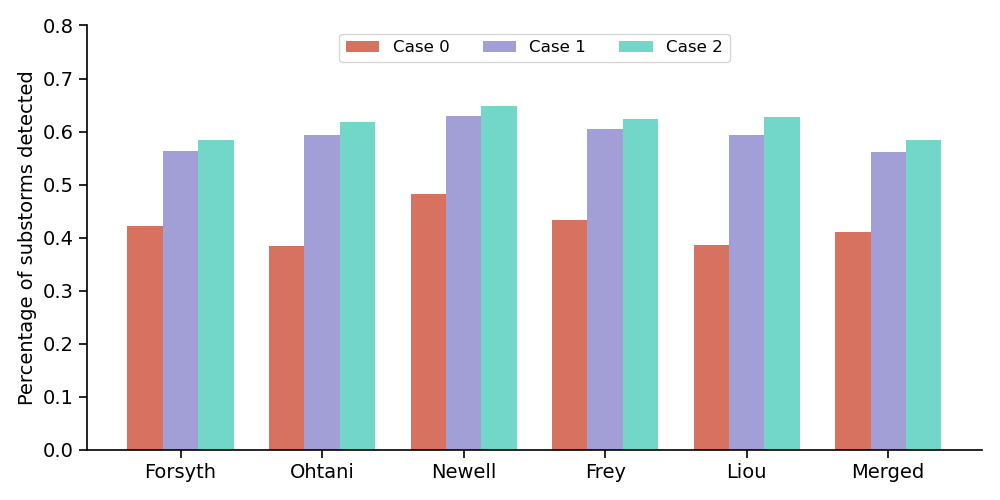

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['Forsyth', 'Ohtani', 'Newell', 'Frey', 'Liou', 'Merged']

W0 = [ss_forsyth_W0, ss_ohtani_W0, ss_newell_W0, ss_frey_W0, ss_liou_W0, ss_merged_0]
W1 = [ss_forsyth_W1, ss_ohtani_W1, ss_newell_W1, ss_frey_W1, ss_liou_W1, ss_merged_1]
W2 = [ss_forsyth_W2, ss_ohtani_W2, ss_newell_W2, ss_frey_W2, ss_liou_W2, ss_merged_2]

x = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, W0, width, label='Case 0', color='#C7361C', alpha=0.7)
ax.bar(x,         W1, width, label='Case 1', color='#7A76C5', alpha=0.7)
ax.bar(x + width, W2, width, label='Case 2', color='#36C7B2', alpha=0.7)
# ax.set_xlabel('Onset identification method')
ax.set_ylabel('Percentage of substorms detected',fontsize=14)
# ax.set_title('Mean WINDMI cases by substorm onset method')
ax.set_xticks(x)
# set yticks to be from 0 to 0.8 with step of 0.1
ax.set_yticks(np.arange(0, 0.9, 0.1))
ax.set_xticklabels(methods, fontsize=14)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)
ax.tick_params(axis='y', labelsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"C:/Users/soumy/OneDrive/Documents/Plots/windmi_detection_comparison.jpg", dpi=300, bbox_inches="tight")
plt.show()

### Figure 3 — Detection by substorm strength and catalog count

Two-panel figure. The top panel stratifies detection by peak SME: weak (SME < 500 nT), moderate (500–1000 nT), and strong (≥ 1000 nT). The bottom panel stratifies by the number of source lists that identified each event (score 1–4). Cases 1–3 are shown as grouped bars in both panels.


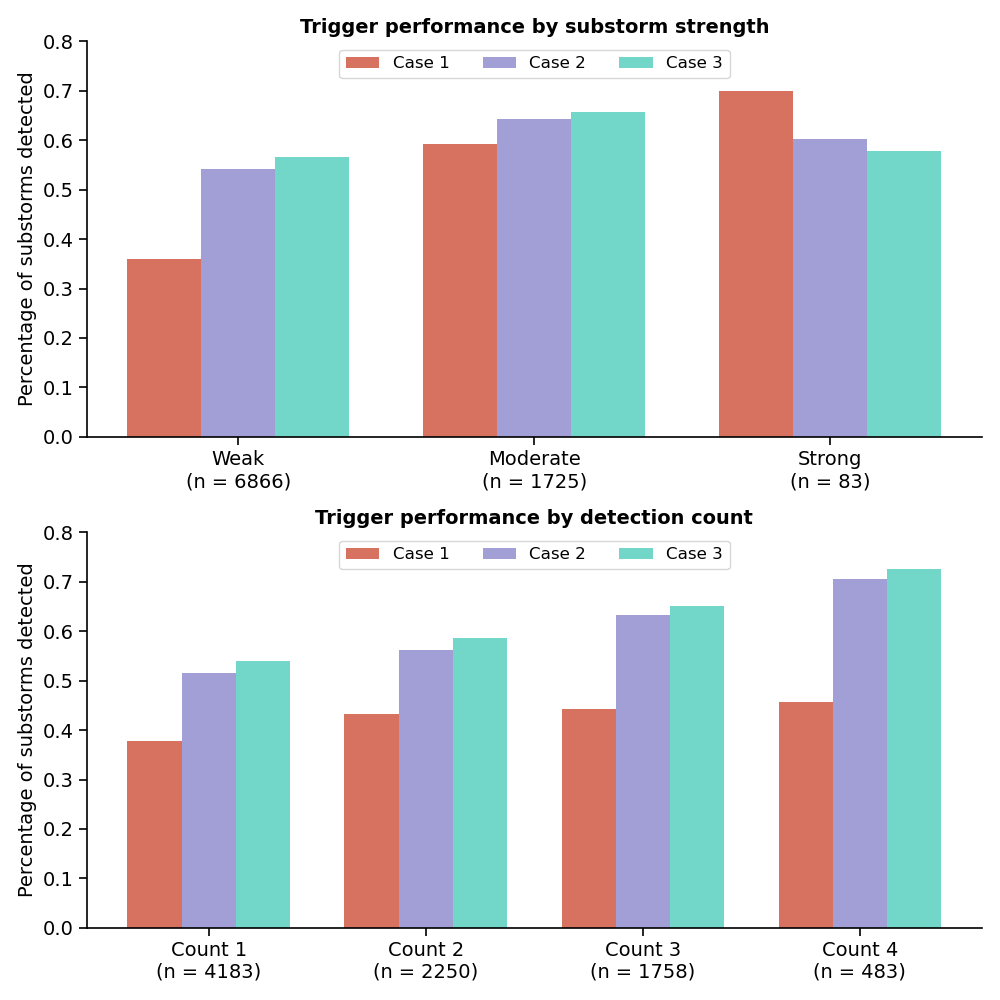

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cases = ['Case 1', 'Case 2', 'Case 3']
colors = ['#C7361C', '#7A76C5', '#36C7B2']
width = 0.25

def fracs(df):
    return [df['windmi_0'].sum()/len(df),
            df['windmi_1'].sum()/len(df),
            df['windmi_2'].sum()/len(df)]

weak     = isolated_substorms[isolated_substorms['SME'] < 500]
moderate = isolated_substorms[(isolated_substorms['SME'] >= 500) & (isolated_substorms['SME'] < 1000)]
strong   = isolated_substorms[isolated_substorms['SME'] >= 1000]
strength_groups = [weak, moderate, strong]
strength_cats = [f'Weak\n(n = {len(weak)})',
                 f'Moderate\n(n = {len(moderate)})',
                 f'Strong\n(n = {len(strong)})']

count_groups = [isolated_substorms[isolated_substorms.score == s] for s in [1, 2, 3, 4]]
count_cats = [f'Count {s}\n(n = {len(df)})' for s, df in zip([1, 2, 3, 4], count_groups)]

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for ax, groups, categories, title in [
    (axes[0], strength_groups, strength_cats, "Trigger performance by substorm strength"),
    (axes[1], count_groups, count_cats, "Trigger performance by detection count"),
]:
    vals = np.array([fracs(df) for df in groups])
    x = np.arange(len(categories))
    ax.bar(x - width, vals[:, 0], width, label=cases[0], color=colors[0], alpha=0.7)
    ax.bar(x,         vals[:, 1], width, label=cases[1], color=colors[1], alpha=0.7)
    ax.bar(x + width, vals[:, 2], width, label=cases[2], color=colors[2], alpha=0.7)

    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Percentage of substorms detected", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=14)
    ax.set_xlim(-0.5, len(categories) - 0.5)   # same per-category span in both
    ax.tick_params(axis='y', labelsize=14)
    ax.set_yticks(np.arange(0, 0.9, 0.1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)

plt.tight_layout()
plt.savefig(f"C:/Users/soumy/OneDrive/Documents/Plots/trigger_performance_comparison_combined_{start.date()}_{stop.date()}.png",
            dpi=300, bbox_inches="tight")
plt.show()

## Θ interval duration analysis

`get_theta_intervals` identifies contiguous blocks where Θ > 0.5 and matches each block to the nearest isolated substorm onset using `merge_asof` with a 15-minute tolerance. The duration of each matched block is recorded. Shorter durations indicate a more targeted trigger response.


In [ ]:
from random import sample


def get_theta_intervals(isolated_substorms, theta_1, threshold=0.5, tolerance_min=15, sampling_resolution='1min'):
    """
    Identifies contiguous blocks where theta > threshold and maps them 
    to the nearest substorm using DatetimeIndexes.
    """
    
    # 1. Extract valid timestamps and group into contiguous blocks
    # Ensure theta_1 is a Series or DataFrame with DatetimeIndex
    theta_valid = theta_1[theta_1 > threshold].to_frame(name='theta_val')
    
    # Identify gaps to separate events
    res_delta = pd.Timedelta(sampling_resolution)
    # diff() on a DatetimeIndex returns a TimedeltaIndex
    theta_valid['block_id'] = (theta_valid.index.to_series().diff() > res_delta).cumsum()
    
    # 2. Calculate start and end for every contiguous block
    # We reset index here to use the 'index' (time) in the groupby
    block_bounds = theta_valid.reset_index().groupby('block_id').agg(
        theta_start=('index', 'min'),
        theta_end=('index', 'max')
    )
    
    # 3. Create a lookup table (must have the time as index for merge_asof)
    theta_lookup = theta_valid[['block_id']].merge(block_bounds, left_on='block_id', right_index=True)
    theta_lookup = theta_lookup.sort_index() # Mandatory for merge_asof
    
    # 4. Preparation for merge_asof
    # Ensure substorms are sorted by their index
    isolated_substorms = isolated_substorms.sort_index()
    
    # 5. Perform the fuzzy join using indexes
    # We use left_index and right_index instead of left_on/right_on
    result = pd.merge_asof(
        isolated_substorms,
        theta_lookup[['theta_start', 'theta_end']],
        left_index=True,
        right_index=True,
        direction='nearest',
        tolerance=pd.Timedelta(minutes=tolerance_min)
    )
    
    return result

# Usage:
# df_final = get_theta_intervals(isolated_substorms, theta_1)

# Usage Example:
df = isolated_substorms[isolated_substorms['windmi_0'] == 1]
df_final0 = get_theta_intervals(df, theta_0, tolerance_min=15)
df_final0 = df_final0.drop_duplicates(subset=['theta_start','theta_end'])
theta_intervals0 = [(df_final0['theta_end'][i] - df_final0['theta_start'][i])/dt.timedelta(minutes=1) for i in range(len(df_final0))]
sample_Size0 = len(df_final0)

df = isolated_substorms[isolated_substorms['windmi_1'] == 1]
df_final1 = get_theta_intervals(df, theta_1, tolerance_min=15)
df_final1 = df_final1.drop_duplicates(subset=['theta_start','theta_end'])
theta_intervals1 = [(df_final1['theta_end'][i] - df_final1['theta_start'][i])/dt.timedelta(minutes=1) for i in range(len(df_final1))]
sample_Size1 = len(df_final1)

df = isolated_substorms[isolated_substorms['windmi_2'] == 1]
df_final2 = get_theta_intervals(df, theta_2, tolerance_min=15)
df_final2 = df_final2.drop_duplicates(subset=['theta_start','theta_end'])
theta_intervals2 = [(df_final2['theta_end'][i] - df_final2['theta_start'][i])/dt.timedelta(minutes=1) for i in range(len(df_final2))]
sample_Size2 = len(df_final2)

### Figure: Θ interval duration histograms

Distribution of matched Θ interval durations for Cases 1–3. Mean and median are shown as vertical lines.


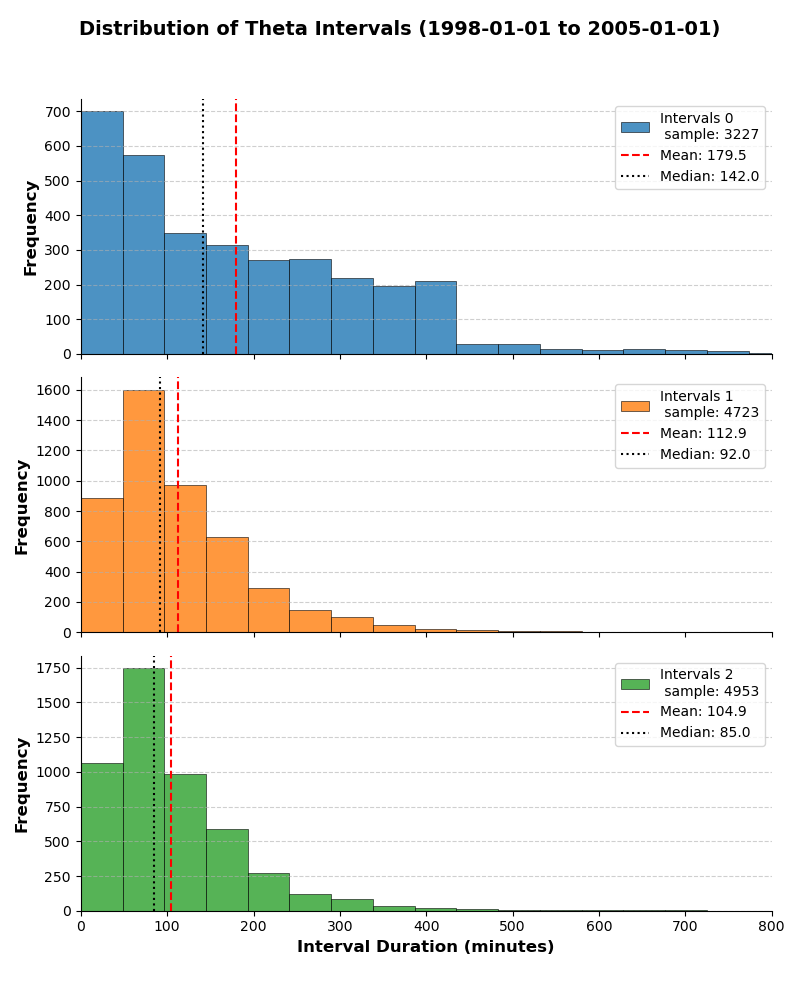

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data consolidation for easier iteration
data_list = [theta_intervals0, theta_intervals1, theta_intervals2]
labels = ['Intervals 0 \n sample: {}'.format(sample_Size0), 
          'Intervals 1 \n sample: {}'.format(sample_Size1), 
          'Intervals 2 \n sample: {}'.format(sample_Size2)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Professional color palette

# Calculate global max for consistent binning
interval_max = max(max(d) for d in data_list if len(d) > 0)
nbin = 30

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for i, ax in enumerate(axes):
    data = data_list[i]
    
    # Histogram with edge color for better bar definition
    n, bins, patches = ax.hist(data, bins=nbin, range=(0, interval_max), 
                               color=colors[i], alpha=0.8, edgecolor='black', 
                               linewidth=0.5, label=labels[i])
    
    # Add vertical lines for Mean and Median
    mean_val = np.mean(data)
    median_val = np.median(data)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='black', linestyle=':', linewidth=1.5, label=f'Median: {median_val:.1f}')
    
    # Aesthetic adjustments
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', frameon=True, fontsize=10)
    
    # Optional: Log scale if data is skewed (common in solar wind/magnetosphere data)
    # ax.set_yscale('log') 
    
    # Remove top/right spines for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlim(0,800)

# Shared X-axis label
axes[2].set_xlabel('Interval Duration (minutes)', fontsize=12, fontweight='bold')
fig.suptitle(f'Distribution of Theta Intervals ({start.date()} to {stop.date()})', 
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_path = f"C:/Users/soumy/OneDrive/Documents/Plots/theta_interval_histograms_{start.date()}_{stop.date()}.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()